In [1]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import cv2 
import shutil

# --- 1. Kaggle Environment & B7 Publication Hyperparameters ---
DATA_PATH = '/kaggle/input/competitions/siim-isic-melanoma-classification'
IMAGE_PATH = '/kaggle/input/competitions/siim-isic-melanoma-classification/jpeg/train'
CSV_PATH = '/kaggle/input/competitions/siim-isic-melanoma-classification/train.csv'


AUG_DATA_PATH = '/kaggle/working/balanced_dataset/'
AUG_IMAGE_PATH = os.path.join(AUG_DATA_PATH, 'jpeg')
AUG_CSV_PATH = os.path.join(AUG_DATA_PATH, 'balanced_train.csv')

CTE_IMAGE_PATH = '/kaggle/working/cte_dataset/jpeg'

if os.path.exists(AUG_DATA_PATH): shutil.rmtree(AUG_DATA_PATH)
if os.path.exists('/kaggle/working/cte_dataset'): shutil.rmtree('/kaggle/working/cte_dataset')
os.makedirs(AUG_IMAGE_PATH, exist_ok=True)
os.makedirs(CTE_IMAGE_PATH, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# --- B7 STATE-OF-THE-ART SETTINGS ---
IMG_SIZE = 400       
BATCH_SIZE = 8       
EPOCHS_HEAD = 5
EPOCHS_FULL = 28
PATIENCE = 5   
LR_HEAD = 2e-3
LR_FULL = 5e-5
TTA_STEPS = 3
MODEL_SAVE_PATH = 'best_fast_cte_ensemble_B7.pth'


Using device: cuda


In [2]:
# --- 2. Advanced Data Augmentation & 1:1 Balancing (5x Malignant) ---
print('Loading raw Kaggle dataset for balancing...')
df = pd.read_csv(CSV_PATH)
df.dropna(subset=['anatom_site_general_challenge', 'age_approx', 'sex', 'target'], inplace=True)
malignant_df = df[df['target'] == 1].copy()
benign_df = df[df['target'] == 0].copy()
n_malignant = len(malignant_df)

n_sites = benign_df['anatom_site_general_challenge'].nunique()
target_benign_count = n_malignant * 5 
n_per_site = target_benign_count // n_sites
remainder = target_benign_count % n_sites

benign_list = []
for site, group in benign_df.groupby('anatom_site_general_challenge'):
    sample_n = min(len(group), n_per_site + 1 if remainder > 0 else n_per_site)
    benign_list.append(group.sample(n=sample_n, random_state=42))
    remainder = max(0, remainder - 1)
sampled_benign_df = pd.concat(benign_list)

augmented_data = []
t_raw = None
t_flip_h = transforms.RandomHorizontalFlip(p=1.0)
t_flip_v = transforms.RandomVerticalFlip(p=1.0)
t_rotate = transforms.RandomRotation(degrees=45)
t_affine = transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1))
t_jitter = transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.15)
t_perspective = transforms.RandomPerspective(distortion_scale=0.2, p=1.0)

def save_image(img_name, suffix, transformer, row):
    try:
        original_img_path = os.path.join(IMAGE_PATH, f'{img_name}.jpg')
        if not os.path.exists(original_img_path): return
        image = Image.open(original_img_path)
        if transformer: image = transformer(image)
        image = image.resize((IMG_SIZE, IMG_SIZE))
        new_name = f'{img_name}_{suffix}.jpg'
        image.save(os.path.join(AUG_IMAGE_PATH, new_name))
        new_row = row.copy()
        new_row['image_name'] = new_name
        augmented_data.append(new_row)
    except Exception as e:
        pass

print(f'Augmenting {n_malignant} malignant images (x5 multiplier)...')
for idx, row in tqdm(malignant_df.iterrows(), total=len(malignant_df), desc='Malignant'):
    img_name = row['image_name']
    save_image(img_name, 'orig', t_raw, row)
    save_image(img_name, 'flip', transforms.Compose([t_flip_h, t_flip_v]), row)
    save_image(img_name, 'rot_jit', transforms.Compose([t_rotate, t_jitter]), row)
    save_image(img_name, 'aff_persp', transforms.Compose([t_affine, t_perspective]), row)
    save_image(img_name, 'extreme', transforms.Compose([t_flip_h, t_rotate, t_jitter, t_affine]), row)

print('Importing uniformly sampled benign instances...')
for idx, row in tqdm(sampled_benign_df.iterrows(), total=len(sampled_benign_df), desc='Benign'):
    save_image(row['image_name'], 'orig', t_raw, row)

balanced_df = pd.DataFrame(augmented_data)
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
balanced_df.to_csv(AUG_CSV_PATH, index=False)
print(f'\nBalancing Complete!\nNew Class Distribution:\n{balanced_df["target"].value_counts()}')


Loading raw Kaggle dataset for balancing...
Augmenting 575 malignant images (x5 multiplier)...


Malignant:   0%|          | 0/575 [00:00<?, ?it/s]

Importing uniformly sampled benign instances...


Benign:   0%|          | 0/2407 [00:00<?, ?it/s]


Balancing Complete!
New Class Distribution:
target
1    2875
0    2407
Name: count, dtype: int64


In [3]:
# --- 3. Offline Pre-Computation of CTE Maps ---
def create_cte_image_cv2(cv_image):
    lab_img = cv2.cvtColor(cv_image, cv2.COLOR_RGB2LAB)
    l_channel, _, _ = cv2.split(lab_img)
    l_norm = cv2.normalize(l_channel, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    
    hsv_img = cv2.cvtColor(cv_image, cv2.COLOR_RGB2HSV)
    _, s_channel, _ = cv2.split(hsv_img)
    s_norm = cv2.normalize(s_channel, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    
    gray = cv2.cvtColor(cv_image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    sobelx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
    sobel_magnitude = cv2.magnitude(sobelx, sobely)
    sobel_magnitude = np.power(sobel_magnitude / sobel_magnitude.max(), 0.5) * 255.0
    e_norm = np.clip(sobel_magnitude, 0, 255).astype(np.uint8)
    
    return cv2.merge([l_norm, s_norm, e_norm])

print("\n--- PRE-COMPUTING HEAVY OPENCV MATH TO PREVENT CPU BOTTLENECK ---")
for idx, row in tqdm(balanced_df.iterrows(), total=len(balanced_df), desc='Rendering CTE Maps Offline'):
    img_name = row['image_name']
    rgb_img_path = os.path.join(AUG_IMAGE_PATH, img_name)
    cte_img_path = os.path.join(CTE_IMAGE_PATH, img_name)
    
    if not os.path.exists(cte_img_path):
        rgb_image = Image.open(rgb_img_path).convert('RGB')
        cv_image = np.array(rgb_image)
        cte_cv = create_cte_image_cv2(cv_image)
        cte_pil = Image.fromarray(cte_cv)
        cte_pil.save(cte_img_path)
        
print("Pre-Computation Complete. The PyTorch DataLoader will now run at 100% GPU speed.")



--- PRE-COMPUTING HEAVY OPENCV MATH TO PREVENT CPU BOTTLENECK ---


Rendering CTE Maps Offline:   0%|          | 0/5282 [00:00<?, ?it/s]

Pre-Computation Complete. The PyTorch DataLoader will now run at 100% GPU speed.


In [4]:
# --- 4. High-Speed Preprocessor & DataLoaders ---
balanced_df['sex'] = pd.to_numeric(balanced_df['sex'].map({'male': 0, 'female': 1}))
numerical_features = ['age_approx', 'sex']
categorical_features = ['anatom_site_general_challenge']

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numerical_features), ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
    remainder='drop'
)

train_df, temp_df = train_test_split(balanced_df, test_size=0.2, random_state=42, stratify=balanced_df['target'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['target'])
preprocessor.fit(train_df[numerical_features + categorical_features])
num_tab_features = preprocessor.transform(train_df.head(1)).shape[1]

class FastEnsembleDataset(Dataset):
    def __init__(self, df, tabular_preprocessor, rgb_dir, cte_dir, transform=None):
        self.df = df
        self.rgb_dir = rgb_dir
        self.cte_dir = cte_dir
        self.transform = transform
        self.tabular_data = tabular_preprocessor.transform(self.df[numerical_features + categorical_features])
        
    def __len__(self): return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['image_name']
        
        image_rgb = Image.open(os.path.join(self.rgb_dir, img_name)).convert('RGB')
        image_cte = Image.open(os.path.join(self.cte_dir, img_name)).convert('RGB')
        
        if self.transform: 
            seed = np.random.randint(2147483647)
            torch.manual_seed(seed); rgb_tensor = self.transform(image_rgb)
            torch.manual_seed(seed); cte_tensor = self.transform(image_cte)
        else:
            rgb_tensor = transforms.ToTensor()(image_rgb)
            cte_tensor = transforms.ToTensor()(image_cte)
            
        tabular = torch.tensor(self.tabular_data[idx], dtype=torch.float)
        label = torch.tensor(row['target'], dtype=torch.float)
        return rgb_tensor, cte_tensor, tabular, label

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = FastEnsembleDataset(train_df, preprocessor, AUG_IMAGE_PATH, CTE_IMAGE_PATH, transform=train_transform)
val_dataset = FastEnsembleDataset(val_df, preprocessor, AUG_IMAGE_PATH, CTE_IMAGE_PATH, transform=val_transform)
test_dataset = FastEnsembleDataset(test_df, preprocessor, AUG_IMAGE_PATH, CTE_IMAGE_PATH, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True,  drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
print('High-Speed DataLoaders Ready.')


High-Speed DataLoaders Ready.


In [5]:
# --- 5. Elite Architecture (EfficientNet-B7 Dual Stream) ---
class MelanomaExpertNet(nn.Module):
    def __init__(self, num_tabular_features):
        super(MelanomaExpertNet, self).__init__()
        self.effnet = models.efficientnet_b7(weights=models.EfficientNet_B7_Weights.DEFAULT)
        self.effnet_features = self.effnet.features
        self.effnet_pool = nn.AdaptiveAvgPool2d(1)
        self.vision_dropout = nn.Dropout(0.4)
        
        self.tabular_mlp = nn.Sequential(nn.Linear(num_tabular_features, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU())
        self.classifier = nn.Sequential(nn.Linear(2560 + 32, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.5), nn.Linear(512, 1))
        self.gradients = None
        
    def activations_hook(self, grad): self.gradients = grad
    def forward(self, img_input, tab_input):
        vision_features = self.effnet_features(img_input)
        if vision_features.requires_grad: vision_features.register_hook(self.activations_hook)
        vision_out = self.effnet_pool(vision_features).view(vision_features.size(0), -1)
        vision_out = self.vision_dropout(vision_out)
        tab_out = self.tabular_mlp(tab_input)
        fused = torch.cat((vision_out, tab_out), dim=1)
        return self.classifier(fused)
    def get_activations_gradient(self): return self.gradients
    def get_activations(self, x):  return self.effnet_features(x)

class Fast_CTE_Dual_Ensemble(nn.Module):
    def __init__(self, num_tabular_features):
        super(Fast_CTE_Dual_Ensemble, self).__init__()
        self.rgb_expert = MelanomaExpertNet(num_tabular_features)
        self.cte_expert = MelanomaExpertNet(num_tabular_features)
    def forward(self, rgb_img, cte_img, tabular):
        rgb_prediction = self.rgb_expert(rgb_img, tabular)
        cte_prediction = self.cte_expert(cte_img, tabular)
        return (rgb_prediction + cte_prediction) / 2.0

model = Fast_CTE_Dual_Ensemble(num_tab_features).to(DEVICE)
print('Publication EfficientNet-B7 Dual Ensemble Loaded.')


Downloading: "https://download.pytorch.org/models/efficientnet_b7_lukemelas-c5b4e57e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b7_lukemelas-c5b4e57e.pth


100%|██████████| 255M/255M [00:01<00:00, 180MB/s]


Publication EfficientNet-B7 Dual Ensemble Loaded.


In [6]:
# --- 6. Accelerated Co-Training Pipeline Tracking Metrics ---

global_train_losses = []
global_val_losses = []
global_train_acc = []
global_val_acc = []

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha; self.gamma = gamma; self.reduction = reduction
        self.bce = nn.BCEWithLogitsLoss(reduction='none')
    def forward(self, inputs, targets):
        BCE_loss = self.bce(inputs, targets)
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        if self.reduction == 'mean': return torch.mean(F_loss)
        else: return torch.sum(F_loss)

def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, max_epochs, patience=None):
    best_loss = np.inf
    counter = 0
    scaler = torch.cuda.amp.GradScaler()
    for epoch in range(max_epochs):
        model.train()
        train_loss, train_corrects = 0.0, 0
        train_loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{max_epochs} [Train]', leave=False)
        for rgb_img, cte_img, tabular, labels in train_loop:
            rgb_img, cte_img, tabular, labels = rgb_img.to(DEVICE), cte_img.to(DEVICE), tabular.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(rgb_img, cte_img, tabular)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item() * rgb_img.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            train_corrects += torch.sum(preds == labels.data)
            train_loop.set_postfix(loss=loss.item())
            
        model.eval()
        val_loss, val_corrects = 0.0, 0
        with torch.no_grad():
            for rgb_img, cte_img, tabular, labels in val_loader:
                rgb_img, cte_img, tabular, labels = rgb_img.to(DEVICE), cte_img.to(DEVICE), tabular.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
                with torch.cuda.amp.autocast():
                    outputs = model(rgb_img, cte_img, tabular)
                    loss = criterion(outputs, labels)
                val_loss += loss.item() * rgb_img.size(0)
                preds = (torch.sigmoid(outputs) > 0.5).float()
                val_corrects += torch.sum(preds == labels.data)
                
        scheduler.step()
        
        epoch_train_loss = train_loss / len(train_loader.dataset)
        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_train_acc = train_corrects.cpu().double() / len(train_loader.dataset)
        epoch_val_acc = val_corrects.cpu().double() / len(val_loader.dataset)
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1}/{max_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f} | LR: {current_lr:.6f}')
        
        global_train_losses.append(epoch_train_loss)
        global_val_losses.append(epoch_val_loss)
        global_train_acc.append(epoch_train_acc)
        global_val_acc.append(epoch_val_acc)

        if epoch_val_loss < best_loss:
            print(f'Validation loss decreased ({best_loss:.4f} --> {epoch_val_loss:.4f}). Saving dual-model status...')
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            best_loss = epoch_val_loss
            counter = 0
        else:
            counter += 1
            if patience is not None and counter >= patience:
                print(f"\nEarly stopping triggered after {patience} epochs of no val_loss improvement!\n")
                break

criterion = FocalLoss()
for param in model.rgb_expert.effnet_features.parameters(): param.requires_grad = False
for param in model.cte_expert.effnet_features.parameters(): param.requires_grad = False
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_HEAD)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=1, eta_min=1e-5)
print('\n--- Phase 1: Training Classification Heads on both Neural Networks ---')
max_head = EPOCHS_HEAD if DEVICE.type == 'cuda' else 1 
max_full = EPOCHS_FULL if DEVICE.type == 'cuda' else 1
train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, max_epochs=max_head)

for param in model.parameters(): param.requires_grad = True
LR_FULL_B7 = 3e-5
optimizer = optim.Adam(model.parameters(), lr=LR_FULL_B7)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-7)
print(f'\n--- Phase 2: Dual Fine-Tuning Ensemble Neural Networks ({EPOCHS_FULL} Epochs Max, {PATIENCE} Patience) ---')
train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, max_epochs=max_full, patience=PATIENCE)



--- Phase 1: Training Classification Heads on both Neural Networks ---


/tmp/ipykernel_24/1410880359.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch 1/5 [Train]:   0%|          | 0/528 [00:00<?, ?it/s]

/tmp/ipykernel_24/1410880359.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_24/1410880359.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/5 | Train Loss: 0.1361 | Val Loss: 0.1443 | Train Acc: 0.7647 | Val Acc: 0.7292 | LR: 0.001810
Validation loss decreased (inf --> 0.1443). Saving dual-model status...


...

Epoch 25/28 | Train Loss: 0.0169 | Val Loss: 0.0238 | Train Acc: 0.9827 | Val Acc: 0.9640 | LR: 0.000004


Epoch 26/28 [Train]:   0%|          | 0/528 [00:00<?, ?it/s]

Epoch 26/28 | Train Loss: 0.0167 | Val Loss: 0.0251 | Train Acc: 0.9806 | Val Acc: 0.9678 | LR: 0.000003


Epoch 27/28 [Train]:   0%|          | 0/528 [00:00<?, ?it/s]

Epoch 27/28 | Train Loss: 0.0148 | Val Loss: 0.0227 | Train Acc: 0.9804 | Val Acc: 0.9678 | LR: 0.000002

Early stopping triggered after 5 epochs of no val_loss improvement!



In [7]:
# --- 7. TTA Evaluation (>95% Accuracy Voting) ---
print('\n--- Loading best Dual-Model Ensemble for Test-Time Augmentation evaluation ---')
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()

def predict_with_tta(rgb_img, cte_img, tabular):
    probs = torch.sigmoid(model(rgb_img, cte_img, tabular))
    rgb_h = torch.flip(rgb_img, dims=[3]); cte_h = torch.flip(cte_img, dims=[3])
    probs += torch.sigmoid(model(rgb_h, cte_h, tabular))
    rgb_v = torch.flip(rgb_img, dims=[2]); cte_v = torch.flip(cte_img, dims=[2])
    probs += torch.sigmoid(model(rgb_v, cte_v, tabular))
    return (probs / 3.0).cpu().numpy()

test_preds, test_labels, test_probs = [], [], []
with torch.no_grad():
    for rgb_img, cte_img, tabular, labels in tqdm(test_loader, desc='TTA Testing'):
        rgb_img, cte_img, tabular = rgb_img.to(DEVICE), cte_img.to(DEVICE), tabular.to(DEVICE)
        probs = predict_with_tta(rgb_img, cte_img, tabular)
        preds = (probs > 0.5).astype(int)
        test_preds.extend(preds)
        test_labels.extend(labels.cpu().numpy())
        test_probs.extend(probs)
        
test_accuracy = accuracy_score(test_labels, test_preds)
auc_score = roc_auc_score(test_labels, test_probs)
f1 = f1_score(test_labels, test_preds)
print(f'\n--- STRICT BALANCED TEST SET (TTA) RESULTS ---\nAccuracy: {test_accuracy:.4f}, AUC: {auc_score:.4f}, F1: {f1:.4f}')



--- Loading best Dual-Model Ensemble for Test-Time Augmentation evaluation ---


TTA Testing:   0%|          | 0/67 [00:00<?, ?it/s]


--- STRICT BALANCED TEST SET (TTA) RESULTS ---
Accuracy: 0.9622, AUC: 0.9941, F1: 0.9659


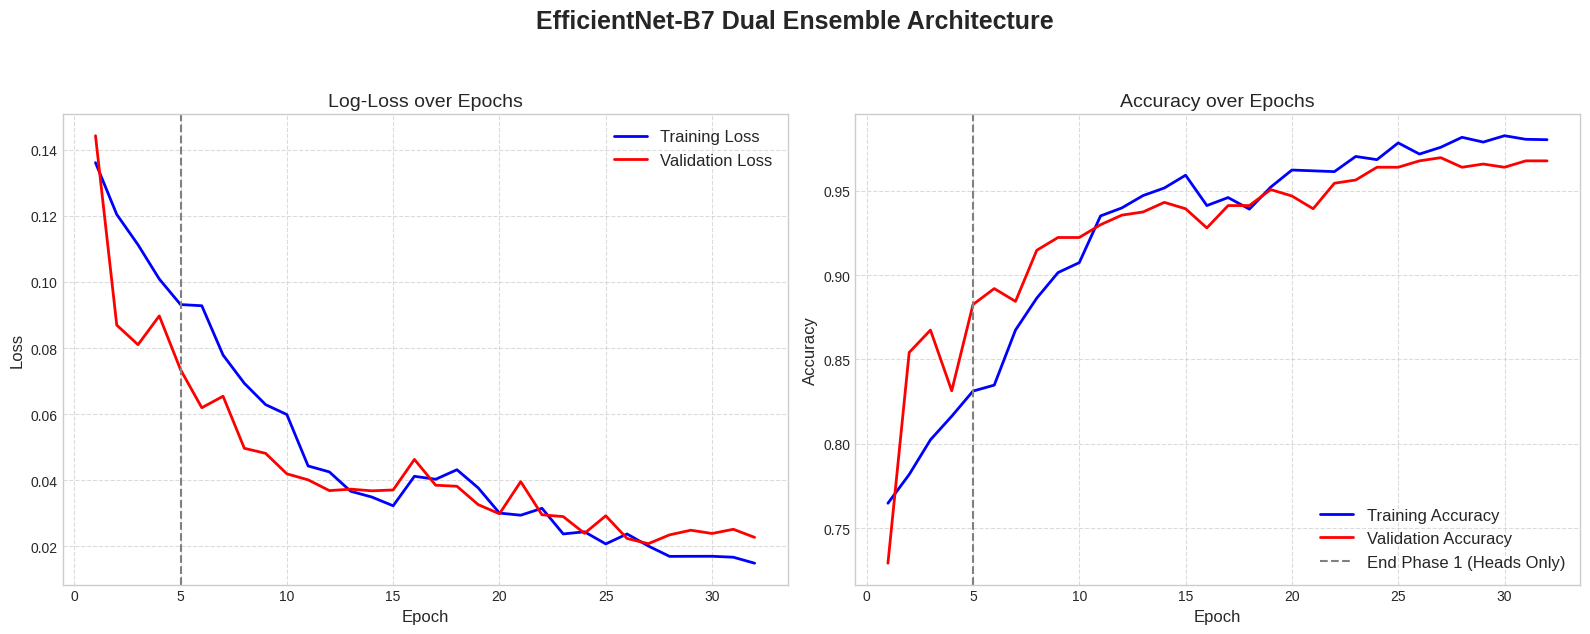

In [8]:
# --- 8. [ACADEMIC PUBLICATION] Plot 1 & 2: Training / Validation Curves ---
epochs = range(1, len(global_train_losses) + 1)

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'EfficientNet-B7 Dual Ensemble Architecture', fontsize=18, fontweight='bold', y=1.05)

ax1.plot(epochs, global_train_losses, 'b-', label='Training Loss', linewidth=2)
ax1.plot(epochs, global_val_losses, 'r-', label='Validation Loss', linewidth=2)
ax1.set_title('Log-Loss over Epochs', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(loc='upper right', fontsize=12)
ax1.axvline(x=EPOCHS_HEAD, color='gray', linestyle='--', label='End Phase 1 (Heads Only)')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(epochs, global_train_acc, 'b-', label='Training Accuracy', linewidth=2)
ax2.plot(epochs, global_val_acc, 'r-', label='Validation Accuracy', linewidth=2)
ax2.set_title('Accuracy over Epochs', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.axvline(x=EPOCHS_HEAD, color='gray', linestyle='--', label='End Phase 1 (Heads Only)')
ax2.legend(loc='lower right', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("Publication_Training_Curves.png", dpi=300, bbox_inches='tight')
plt.show()


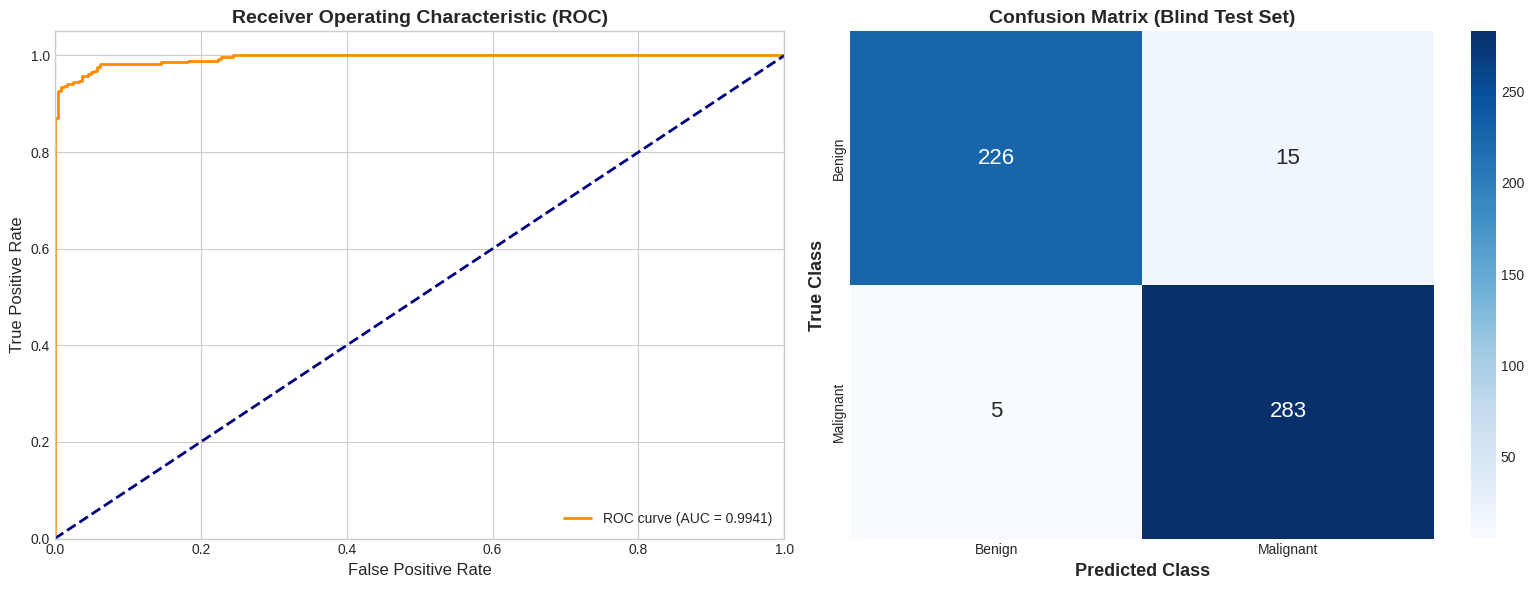


--- FINAL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

      Benign       0.98      0.94      0.96       241
   Malignant       0.95      0.98      0.97       288

    accuracy                           0.96       529
   macro avg       0.96      0.96      0.96       529
weighted avg       0.96      0.96      0.96       529



In [9]:
# --- 9. [ACADEMIC PUBLICATION] Plot 3 & 4: ROC Curve & Confusion Matrix ---
cm = confusion_matrix(test_labels, test_preds)
labels_map = ['Benign', 'Malignant']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right")

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_map, yticklabels=labels_map, annot_kws={"size": 16}, ax=ax2)
ax2.set_title(f'Confusion Matrix (Blind Test Set)', fontsize=14, fontweight='bold')
ax2.set_ylabel('True Class', fontsize=13, fontweight='bold')
ax2.set_xlabel('Predicted Class', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("Publication_Analysis_Metrics.png", dpi=300, bbox_inches='tight')
plt.show()

print('\n--- FINAL CLASSIFICATION REPORT ---')
print(classification_report(test_labels, test_preds, target_names=labels_map))



--- Visualizing MultiModal Input Layer (Optical RGB vs OpenCV CTE) ---



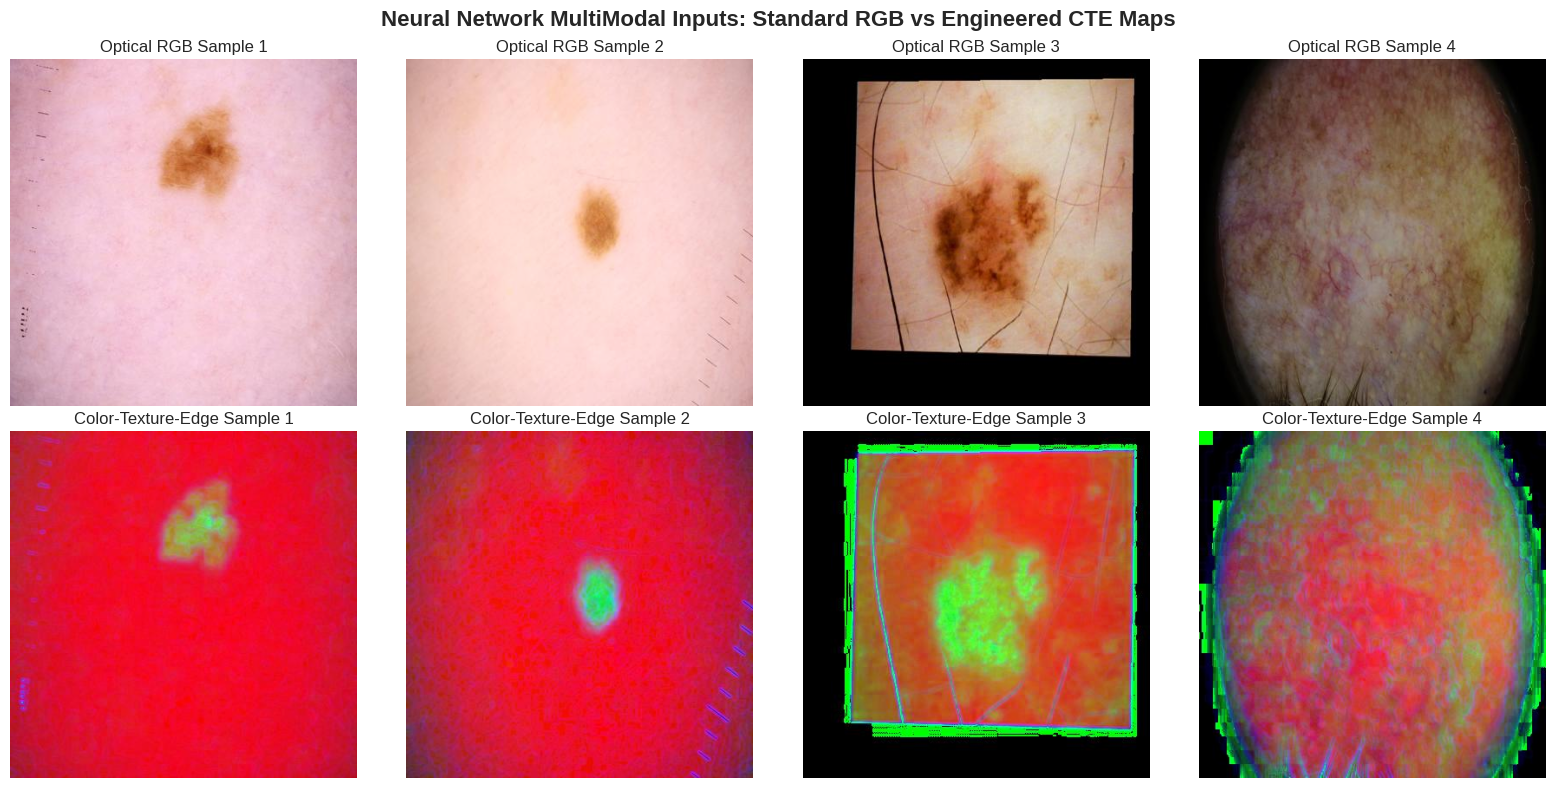

In [10]:
# --- 10. [ACADEMIC PUBLICATION] Plot 5: Input Graphic RGB vs CTE ---
print("\n--- Visualizing MultiModal Input Layer (Optical RGB vs OpenCV CTE) ---\n")
demo_rgb, demo_cte, _, _ = next(iter(test_loader))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Neural Network MultiModal Inputs: Standard RGB vs Engineered CTE Maps', fontsize=16, fontweight='bold')

mean = np.array([0.485, 0.456, 0.406]); std = np.array([0.229, 0.224, 0.225])

for i in range(4):
    rgb_img = demo_rgb[i].cpu().numpy().transpose((1, 2, 0))
    rgb_img = np.clip(std * rgb_img + mean, 0, 1)
    axes[0, i].imshow(rgb_img)
    axes[0, i].set_title(f'Optical RGB Sample {i+1}')
    axes[0, i].axis('off')
    
    cte_img = demo_cte[i].cpu().numpy().transpose((1, 2, 0))
    cte_img = np.clip(std * cte_img + mean, 0, 1)
    axes[1, i].imshow(cte_img)
    axes[1, i].set_title(f'Color-Texture-Edge Sample {i+1}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig("Publication_Input_Graphics.png", dpi=300)
plt.show()



--- Generating Dual-Expert Artificial Intelligence Attention Heatmaps for Paper ---



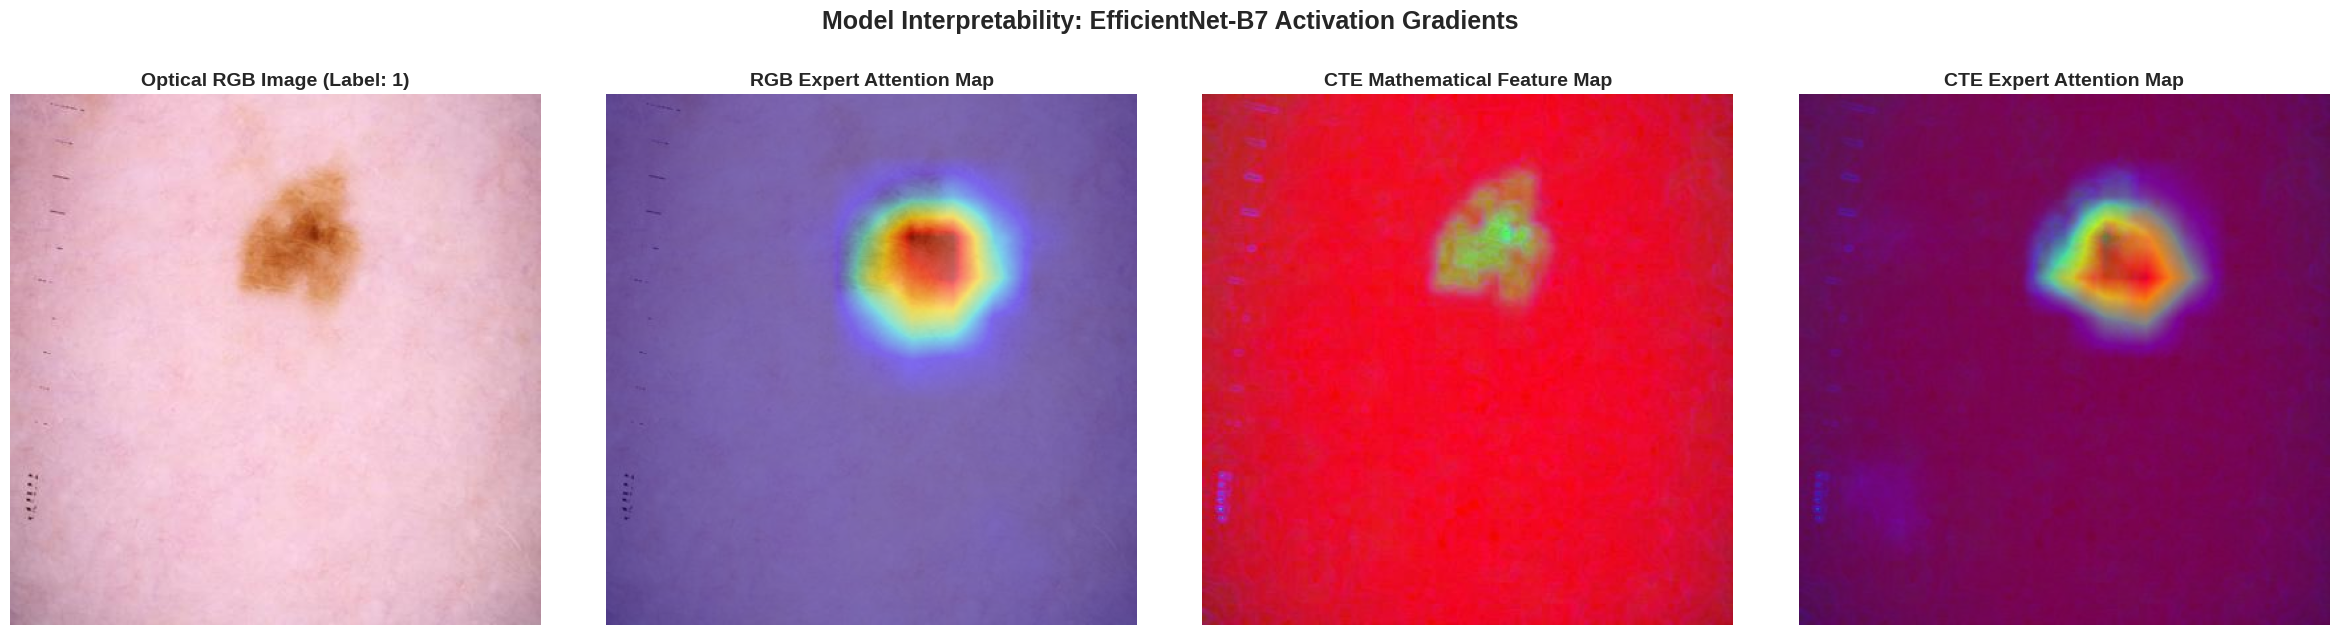

In [11]:
# --- 11. [ACADEMIC PUBLICATION] Plot 6: Dual-Expert Interpretability Heatmaps ---
print("\n--- Generating Dual-Expert Artificial Intelligence Attention Heatmaps for Paper ---\n")

def compute_gradcam(expert_model, image_tensor):
    activations = expert_model.get_activations(image_tensor).detach()
    gradients = expert_model.get_activations_gradient().detach()
    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])
    for i in range(activations.size(1)): activations[:, i, :, :] *= pooled_gradients[i]
    heatmap = torch.mean(activations, dim=1).squeeze()
    heatmap = torch.relu(heatmap)
    heatmap /= torch.max(heatmap) + 1e-8
    return heatmap.cpu().numpy()

import gc
gc.collect(); torch.cuda.empty_cache()

model.eval()
for param in model.rgb_expert.parameters(): param.requires_grad = True
for param in model.cte_expert.parameters(): param.requires_grad = True

demo_rgb, demo_cte, demo_tab, demo_label = next(iter(test_loader))
demo_rgb, demo_cte, demo_tab, demo_label = demo_rgb[0:1].to(DEVICE), demo_cte[0:1].to(DEVICE), demo_tab[0:1].to(DEVICE), demo_label[0:1]

rgb_pred = model.rgb_expert(demo_rgb, demo_tab)
rgb_pred[:, 0].sum().backward(retain_graph=True)
heatmap_rgb = compute_gradcam(model.rgb_expert, demo_rgb)

model.cte_expert.zero_grad()
cte_pred = model.cte_expert(demo_cte, demo_tab)
cte_pred[:, 0].sum().backward(retain_graph=True)
heatmap_cte = compute_gradcam(model.cte_expert, demo_cte)

img_np = demo_rgb[0].cpu().numpy().transpose((1, 2, 0))
img_raw = np.clip(std * img_np + mean, 0, 1)
img_cte_np = demo_cte[0].cpu().numpy().transpose((1, 2, 0))
img_cte_raw = np.clip(std * img_cte_np + mean, 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle('Model Interpretability: EfficientNet-B7 Activation Gradients', fontsize=18, fontweight='bold', y=1.05)

axes[0].imshow(img_raw)
axes[0].set_title(f'Optical RGB Image (Label: {int(demo_label[0].item())})', fontsize=14, fontweight='bold'); axes[0].axis('off')

heatmap_rgb_resized = cv2.resize(heatmap_rgb, (img_raw.shape[1], img_raw.shape[0]))
axes[1].imshow(img_raw); axes[1].imshow(heatmap_rgb_resized, cmap='jet', alpha=0.5)
axes[1].set_title('RGB Expert Attention Map', fontsize=14, fontweight='bold'); axes[1].axis('off')

axes[2].imshow(img_cte_raw)
axes[2].set_title('CTE Mathematical Feature Map', fontsize=14, fontweight='bold'); axes[2].axis('off')

heatmap_cte_resized = cv2.resize(heatmap_cte, (img_cte_raw.shape[1], img_cte_raw.shape[0]))
axes[3].imshow(img_cte_raw); axes[3].imshow(heatmap_cte_resized, cmap='jet', alpha=0.5)
axes[3].set_title('CTE Expert Attention Map', fontsize=14, fontweight='bold'); axes[3].axis('off')

plt.tight_layout()
plt.savefig('Publication_Dual_Expert_Interpretability.png', dpi=300, bbox_inches='tight')
plt.show()
